# Laboratorijska vježba 5 — segmentacija watershed postupkom

Implementirane su sve tražene faze: CLAHE, Otsu, morfološko otvaranje, sigurna pozadina, transformacija udaljenosti, markeri i watershed. Rezultat se uspoređuje i bez CLAHE-a.

In [1]:
from pathlib import Path
import math
import time
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

IMG = Path('images')

def show(images, titles, cmaps=None, figsize=(15, 5)):
    """Prikaži jednu ili više slika bez skrivene promjene raspona vrijednosti."""
    if not isinstance(images, (list, tuple)):
        images, titles = [images], [titles]
    if cmaps is None:
        cmaps = [None] * len(images)
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    axes = np.atleast_1d(axes)
    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def watershed_segmentation(image_bgr, use_clahe=True):
    gray = cv.cvtColor(image_bgr, cv.COLOR_BGR2GRAY)
    if use_clahe:
        clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray = clahe.apply(gray)

    # Stanice su tamnije od pozadine, zato se koristi THRESH_BINARY_INV.
    otsu_t, thresholded = cv.threshold(
        gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU
    )
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
    opening = cv.morphologyEx(thresholded, cv.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv.dilate(opening, kernel, iterations=3)

    dist = cv.distanceTransform(opening, cv.DIST_L2, 3)
    dist_norm = cv.normalize(dist, None, 0, 1.0, cv.NORM_MINMAX)
    _, sure_fg = cv.threshold(dist_norm, 0.20 * dist_norm.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv.subtract(sure_bg, sure_fg)

    _, markers = cv.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    markers = cv.watershed(image_bgr.copy(), markers.astype(np.int32))

    labels = [v for v in np.unique(markers) if v > 1]
    rng = np.random.default_rng(42)
    colors = {label: rng.integers(40, 256, 3, dtype=np.uint8) for label in labels}
    colored = np.zeros_like(image_bgr)
    for label, color in colors.items():
        colored[markers == label] = color
    colored[markers == -1] = (0, 0, 255)

    overlay = image_bgr.copy()
    overlay[markers == -1] = (0, 0, 255)
    return {
        'gray': gray, 'otsu_t': otsu_t, 'thresholded': thresholded,
        'opening': opening, 'sure_bg': sure_bg, 'distance': dist_norm,
        'markers': markers, 'colored': colored, 'overlay': overlay,
        'count': len(labels)
    }

img = cv.imread(str(IMG / 'cells.jpg'))
assert img is not None, 'Slika nije pronađena.'

## Segmentacija s CLAHE-om

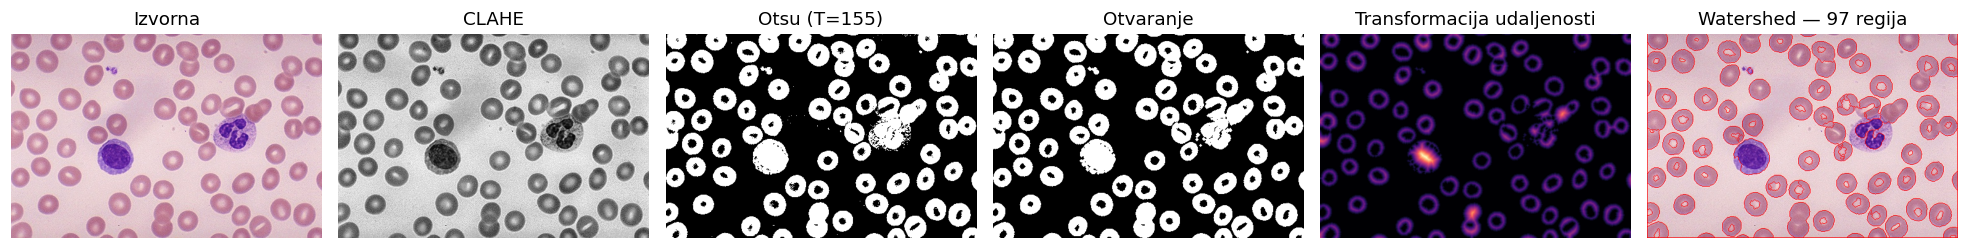

In [2]:
result_clahe = watershed_segmentation(img, use_clahe=True)
show(
    [cv.cvtColor(img, cv.COLOR_BGR2RGB), result_clahe['gray'],
     result_clahe['thresholded'], result_clahe['opening'],
     result_clahe['distance'], cv.cvtColor(result_clahe['overlay'], cv.COLOR_BGR2RGB)],
    ['Izvorna', 'CLAHE', f"Otsu (T={result_clahe['otsu_t']:.0f})",
     'Otvaranje', 'Transformacija udaljenosti',
     f"Watershed — {result_clahe['count']} regija"],
    [None, 'gray', 'gray', 'gray', 'magma', None], figsize=(18, 8)
)
cv.imwrite('images/thresholded.png', result_clahe['thresholded'])
cv.imwrite('images/distance_transform.png', np.uint8(result_clahe['distance'] * 255))
cv.imwrite('images/result_original.png', result_clahe['colored'])

## Usporedba bez CLAHE-a

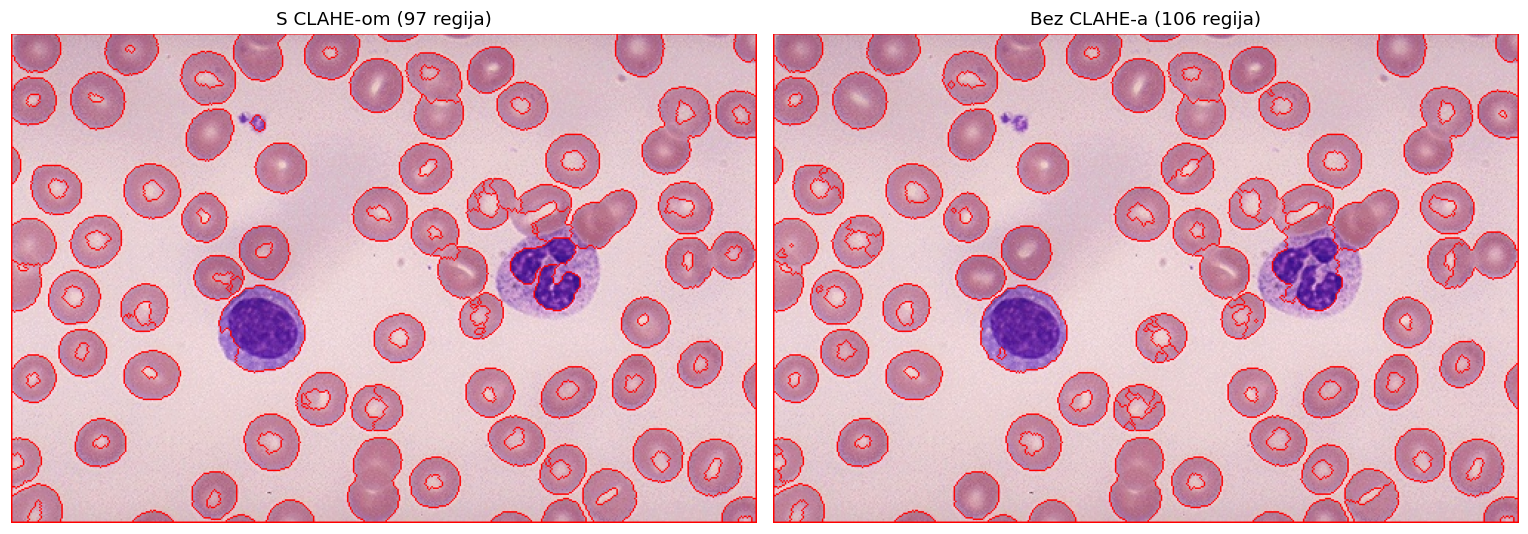

In [3]:
result_plain = watershed_segmentation(img, use_clahe=False)
cv.imwrite('images/result.png', result_plain['colored'])
show(
    [cv.cvtColor(result_clahe['overlay'], cv.COLOR_BGR2RGB),
     cv.cvtColor(result_plain['overlay'], cv.COLOR_BGR2RGB)],
    [f"S CLAHE-om ({result_clahe['count']} regija)",
     f"Bez CLAHE-a ({result_plain['count']} regija)"],
    figsize=(14, 6)
)

**Komentar usporedbe:** CLAHE lokalno povećava kontrast slabo izraženih rubova stanica. Zato markeri i watershed granice mogu bolje pratiti stanice nejednake svjetline. Bez CLAHE-a slabije granice nestaju, pa se susjedne stanice češće spajaju (podsegmentacija). Istodobno, prenaglašen lokalni šum može proizvesti dodatne markere i nadsegmentaciju.

## Označavanje primjera nadsegmentacije i podsegmentacije

Najmanja dobivena regija označava se kao kandidat za nadsegmentaciju, a najveća kao kandidat za podsegmentaciju. Oznake su dijagnostičke: konačna procjena zahtijeva ručni pregled anatomskih granica.

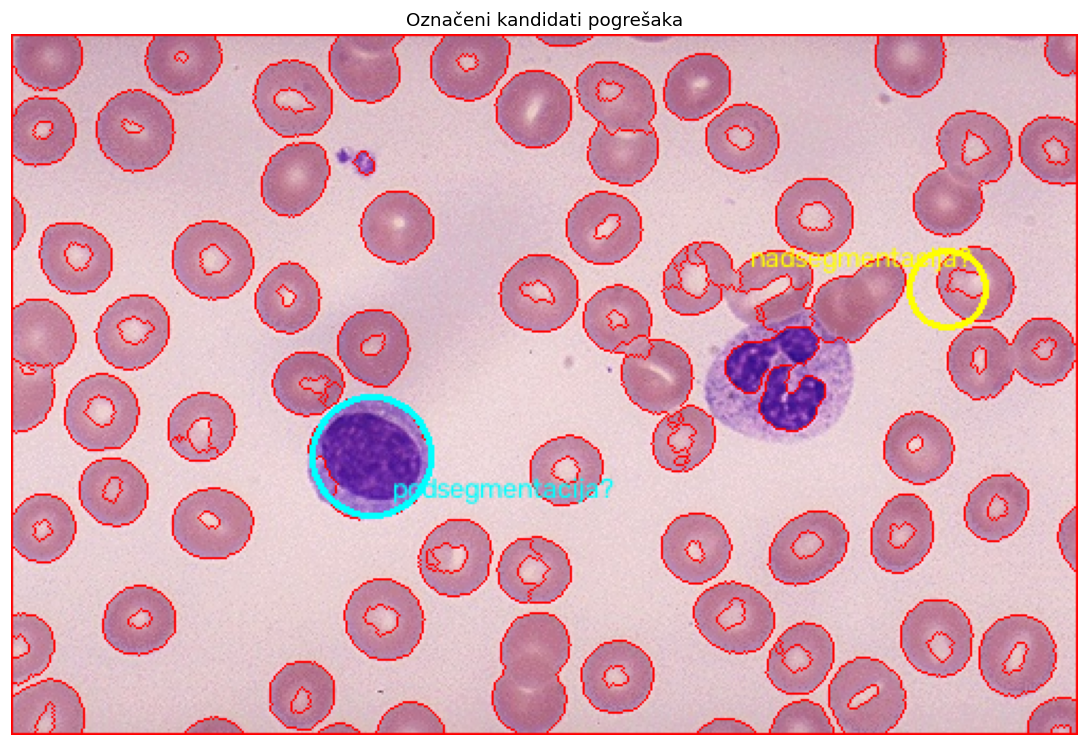

In [4]:
markers = result_clahe['markers']
labels, counts = np.unique(markers[markers > 1], return_counts=True)
annotated = result_clahe['overlay'].copy()

def label_center(label):
    ys, xs = np.where(markers == label)
    return (int(np.mean(xs)), int(np.mean(ys)))

if len(labels):
    small_label = labels[np.argmin(counts)]
    large_label = labels[np.argmax(counts)]
    small_center = label_center(small_label)
    large_center = label_center(large_label)
    cv.circle(annotated, small_center, 18, (0, 255, 255), 2)
    h, w = annotated.shape[:2]
    small_text = (max(5, min(small_center[0] + 10, w - 155)),
                  max(18, small_center[1] - 10))
    large_text = (max(5, min(large_center[0] + 10, w - 155)),
                  min(h - 8, large_center[1] + 20))
    cv.putText(annotated, 'nadsegmentacija?', small_text,
               cv.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1, cv.LINE_AA)
    cv.circle(annotated, large_center, 28, (255, 255, 0), 2)
    cv.putText(annotated, 'podsegmentacija?', large_text,
               cv.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 0), 1, cv.LINE_AA)

cv.imwrite('images/result_annotated.png', annotated)
show(cv.cvtColor(annotated, cv.COLOR_BGR2RGB), 'Označeni kandidati pogrešaka', figsize=(10, 8))

## Zaključak

Watershed uspješno odvaja mnoge dodirne stanice kada su markeri dobro postavljeni. Ključni parametri su prag sigurne prednje regije, broj morfoloških iteracija i lokalno pojačanje kontrasta. Premalo markera uzrokuje spajanje objekata, a previše markera cijepa jednu stanicu na više regija.